In [ ]:
# Import useful packages for galactic unresolved stellar population synthesis (SPS) modeling
import numpy as np
import matplotlib.pyplot as plt
import fsps

# Needed to export the directory so fsps knows where to look. I thought I only
# had to do this once when I intalled, but I need to do it every time. Gemini
# had me put it in my conda env config file because I didn't want to clutter my
# bashrc. First I activated the ay_250 env, then I ran conda env config vars set SPS_HOME="/path/"
# and then I had to reactivate the env but now it works
# export SPS_HOME="/mnt/c/Users/noahs/Desktop/Berkeley/Year 1/Semester 2/Stellar Pops/fsps"

In [16]:
# Generate a spectra of a galaxy with a single burst of star formation at 10 Gyr ago, with solar metallicity
age = 10.0 # Gyr
sp = fsps.StellarPopulation(zcontinuous=1, logzsol=0.0, # Solar metallicity
                            dust_type=2, dust2=0.2, # Calzetti et al. (2000) attenuation law. A_V = 0.2 mag
                             sfh=0, tage=age) # Single burst, Age of the stellar population in Gyr
# Use the MIST isochrones, which are continuous in metallicity, interpolated between the discrete metallicity values of the original Padova isochrones. This allows for more accurate modeling of stellar populations with a range of metallicities.
wavelengths, spectrum = sp.get_spectrum(tage=age, peraa=True) # Set tage so it interpolates the grid for us
# Wavelengths in Angstroms, spectrum in L_sun/Angstrom

In [17]:
# See what wavelengths we're working with
print("Number of wavelength points:", len(wavelengths))
print("Wavelengths in nice units:", min(wavelengths) / 10, "nm", max(wavelengths) / 1e7, "mm")

Number of wavelength points: 5994
Wavelengths in nice units: 9.1 nm 10.0 mm


In [18]:
# Explore the spectrum object
print("Spectrum shape:", spectrum.shape)

Spectrum shape: (5994,)


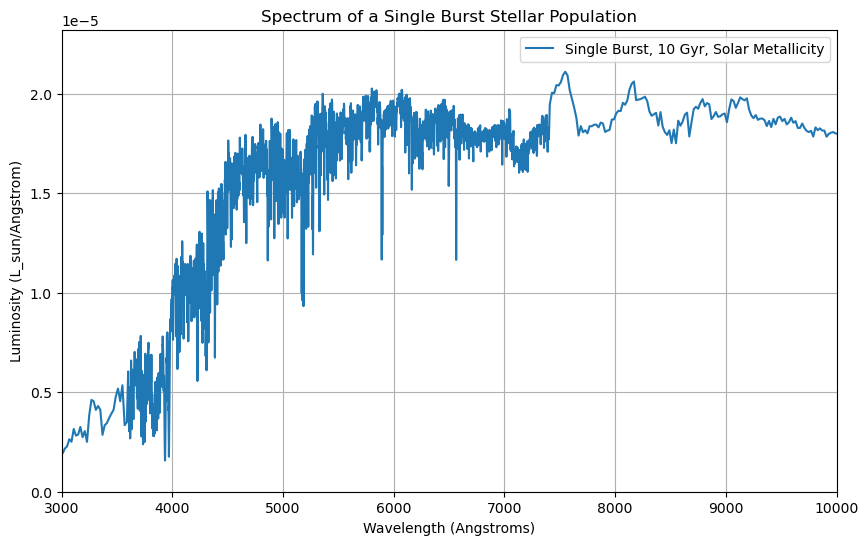

In [19]:
# Plot the spectrum
plt.figure(figsize=(10, 6))
plt.plot(wavelengths, spectrum, label='Single Burst, 10 Gyr, Solar Metallicity')
plt.xlabel('Wavelength (Angstroms)')
plt.ylabel('Luminosity (L_sun/Angstrom)')
plt.title('Spectrum of a Single Burst Stellar Population')
plt.legend()
plt.xlim(3000, 10000)  # Focus on the optical range
plt.ylim(0, np.max(spectrum) * 1.1)
plt.grid()
plt.show()

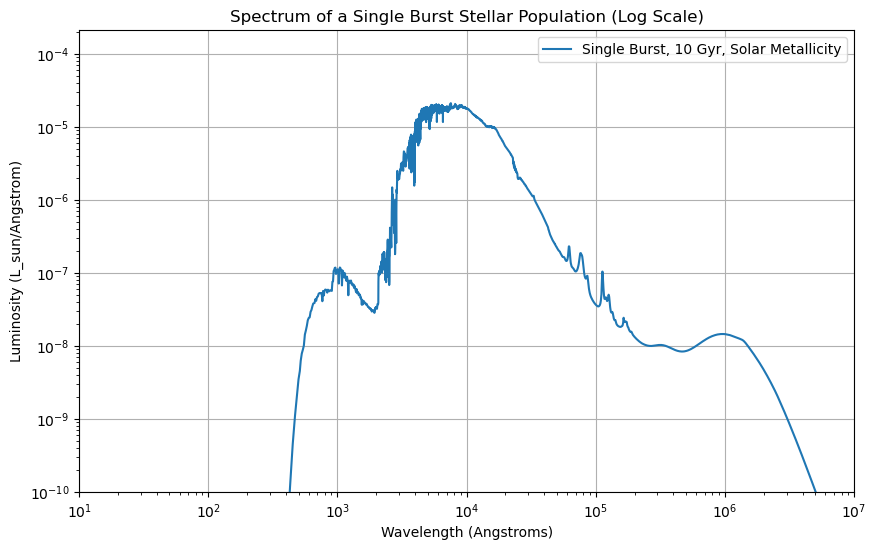

In [29]:
# Plot the full spectrum on a log scale to see the UV and IR features
plt.figure(figsize=(10, 6))
plt.plot(wavelengths, spectrum, label='Single Burst, 10 Gyr, Solar Metallicity')
plt.xlabel('Wavelength (Angstroms)')
plt.ylabel('Luminosity (L_sun/Angstrom)')
plt.title('Spectrum of a Single Burst Stellar Population (Log Scale)')
plt.legend()

# Plot from the xUV to the radio
plt.xlim(10, 1e7)  # xUV to radio
plt.xscale('log')
plt.ylim(1e-10, np.max(spectrum) * 10)
plt.yscale('log')
plt.grid()
plt.show()

In [51]:
# Show the effect of dust reddening by generating a few spectra of star-forming
# galaxies

# --- SECTION 1: DATA GENERATION ---
# Run this once. 
sp = fsps.StellarPopulation(zcontinuous=1, logzsol=0.0, 
                            sfh=4, tau=1.0, 
                            dust_type=2,
                            add_neb_emission=True, 
                            add_dust_emission=True)

# dust_depths = [0.0, 0.5, 2.0, 5.0, 10.0]
dust_depths = [0.0, 2.0, 5.0]
age = 5.0

# Store results in a dictionary: {dust_value: spectrum_array}
sed_data = {}
wave, _ = sp.get_spectrum(tage=age, peraa=True) # Get wavelength grid once

for d in dust_depths:
    sp.params['dust2'] = d
    _, spec = sp.get_spectrum(tage=age, peraa=True)
    sed_data[d] = spec.copy() # Store a copy of the spectrum

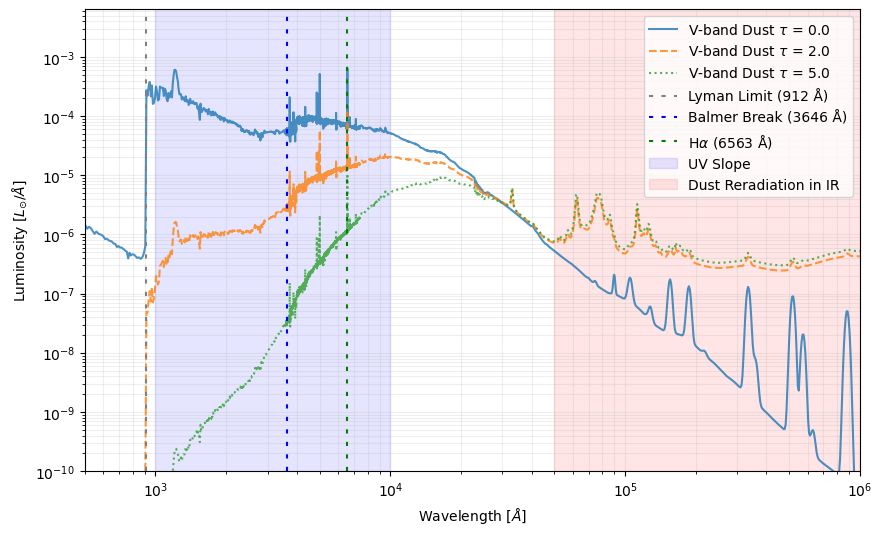

In [66]:

# --- SECTION 2: PLOTTING FUNCTION ---
def plot_galaxy_sed(wave, data_dict, xlim=(500, 1e6), title="Galaxy SED"):
    # Generate figure
    plt.figure(figsize=(10, 6))
    
    # Plot each spectrum with a label indicating the dust depth
    styles = ['-', '--', ':']
    for i, (d, spec) in enumerate(data_dict.items()):
        plt.plot(wave, spec, label=f'V-band Dust $\\tau$ = {d}', alpha=0.8, linestyle=styles[i])
    
    # Plot specific lines
    plt.axvline(912, color='gray', linestyle='--', label='Lyman Limit (912 Å)', dashes=[2, 4])
    # plt.axvline(2175, color='red', linestyle='--', label='UV Bump (2175 Å)')
    plt.axvline(3646, color='blue', linestyle='--', label=r'Balmer Break (3646 Å)', dashes=[2, 4])
    # plt.axvline(4861, color='orange', linestyle='--', label=r'H$\beta$ (4861 Å)')
    # plt.axvline(5007, color='purple', linestyle='--', label=r'[O III] (5007 Å)')
    plt.axvline(6563, color='green', linestyle='--', label=r'H$\alpha$ (6563 Å)', dashes=[2, 4])

    # Show regions
    plt.axvspan(1e3, 1e4, color='blue', alpha=0.1, label='UV Slope')
    plt.axvspan(5e4, 1e6, color='red', alpha=0.1, label="Dust Reradiation in IR")

    # Set scales and limits
    plt.xscale('log')
    plt.yscale('log')
    plt.xlim(xlim)
    plt.ylim(1e-10, np.max(list(data_dict.values())) * 10)
    
    # Set labels
    plt.xlabel(r'Wavelength [$\AA$]')
    plt.ylabel(r'Luminosity [$L_{\odot} / \AA$]')
    # plt.title(title)
    plt.legend()
    plt.grid(True, which="both", ls="-", alpha=0.2)
    plt.show()

# Now you can call this as many times as you want with different settings!
plot_galaxy_sed(wave, sed_data)